# **Задание №5: Формирование календарного плана проекта и управление рисками**



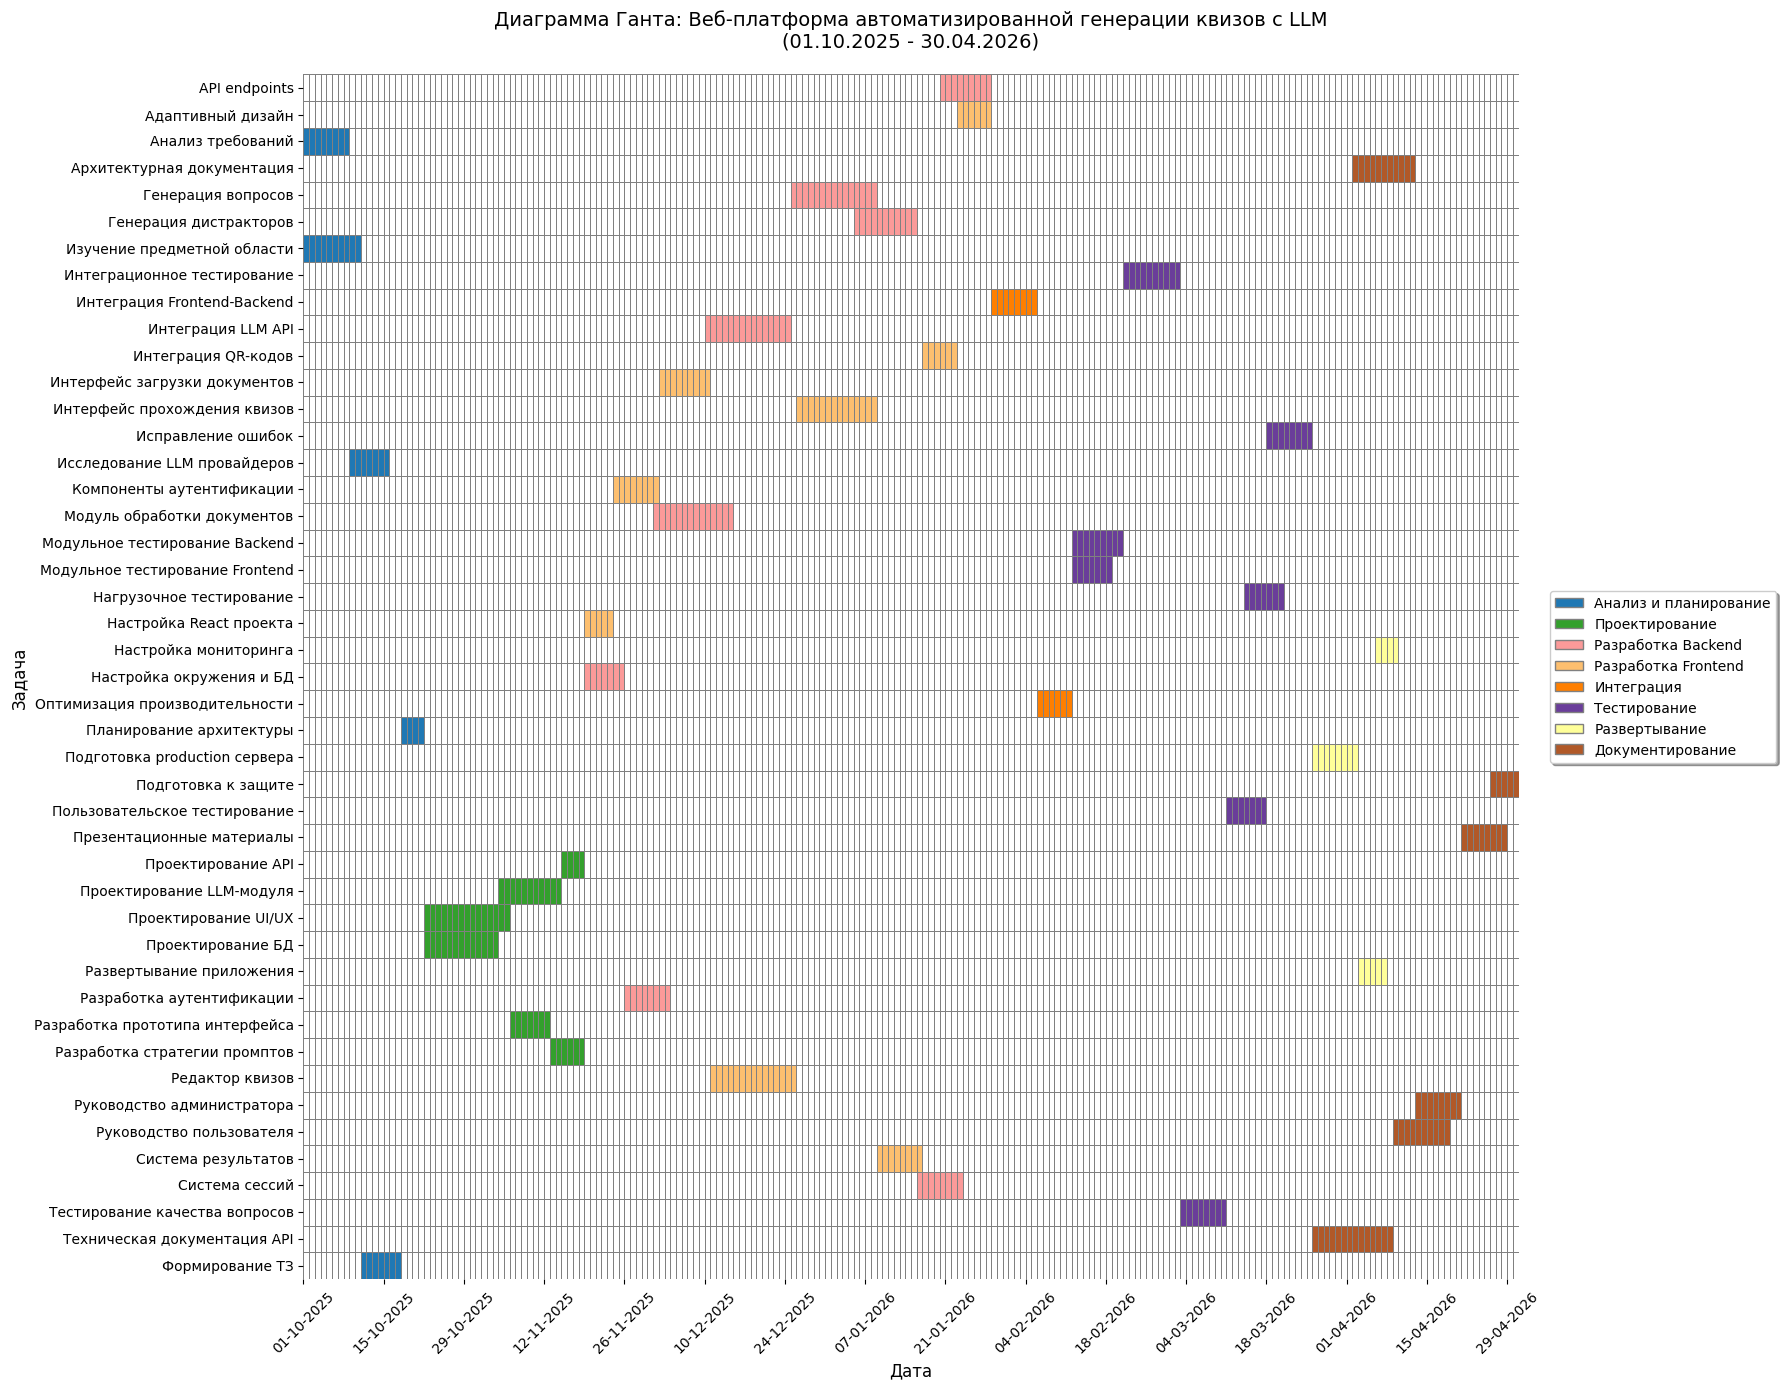

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

def create_gantt_chart(tasks, title="Диаграмма Ганта", save_path="gantt_chart.png", figsize=(16, 8)):
    """
    Создает и сохраняет диаграмму Ганта в виде таблицы на основе предоставленных данных о задачах.
    """
    # Создание DataFrame и преобразование дат
    df = pd.DataFrame(tasks)
    df['Start'] = pd.to_datetime(df['Start'])
    df['End'] = pd.to_datetime(df['End'])

    # Определение временного диапазона проекта
    project_start = df['Start'].min().date()
    project_end = df['End'].max().date()
    project_duration = (project_end - project_start).days + 1

    # Создание всех дат проекта
    all_dates = [project_start + timedelta(days=i) for i in range(project_duration)]
    date_labels = [date.strftime('%d-%m') for date in all_dates]

    # Создание длинного формата данных для heatmap
    gantt_data = []
    for i, task in enumerate(df.itertuples()):
        task_start = task.Start.date()
        task_end = task.End.date()
        for date in all_dates:
            is_active = 1 if task_start <= date <= task_end else 0
            gantt_data.append({
                'Task': task.Task,
                'Date': date.strftime('%Y-%m-%d'),
                'Active': is_active,
                'Group': task.Group
            })

    # Преобразование в DataFrame
    gantt_df = pd.DataFrame(gantt_data)

    # Преобразование в матричный формат для heatmap
    gantt_matrix = gantt_df.pivot(index='Task', columns='Date', values='Active')

    # Получение уникальных групп задач
    groups = df['Group'].unique()

    # Создание цветовой схемы для групп
    group_values = {group: i+1 for i, group in enumerate(groups)}

    # Создание матрицы с группами
    group_matrix = np.zeros_like(gantt_matrix.values)
    for i, task in enumerate(gantt_matrix.index):
        group = df[df['Task'] == task]['Group'].values[0]
        group_value = group_values[group]
        active_indices = np.where(gantt_matrix.iloc[i, :] == 1)
        group_matrix[i, active_indices] = group_value

    # Настройка цветовой схемы
    num_colors = len(group_values) + 1
    cmap = plt.colormaps['Paired']
    colors = [cmap(i/(num_colors-1)) for i in range(num_colors)]
    custom_cmap = plt.matplotlib.colors.ListedColormap(['white'] + colors[1:])

    # Создание фигуры с дополнительным пространством для легенды
    fig, ax = plt.subplots(figsize=figsize)

    # Создание heatmap с seaborn
    ax = sns.heatmap(group_matrix, cmap=custom_cmap, cbar=False,
                    linewidths=.5, linecolor='gray',
                    xticklabels=date_labels, yticklabels=gantt_matrix.index, ax=ax)

    # Настройка осей
    ax.set_title(title, fontsize=14, pad=20)
    ax.set_xlabel('Дата', fontsize=12)
    ax.set_ylabel('Задача', fontsize=12)

    # Настройка частоты меток по оси X (каждые 14 дней)
    tick_positions = np.arange(0, project_duration, 14)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([all_dates[pos].strftime('%d-%m-%Y') for pos in tick_positions], rotation=45)

    # Добавление сетки для двух недель
    for week_pos in tick_positions:
        plt.axvline(x=week_pos, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

    # Добавление легенды вне области графика
    legend_elements = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[group_values[group]],
                                    edgecolor='gray', label=group)
                      for group in group_values.keys()]

    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
             fontsize=10, frameon=True, fancybox=True, shadow=True)

    # Оптимизация размещения
    plt.tight_layout()

    # Сохранение с высоким разрешением
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# Задачи проекта генерации квизов (расширенный период: 01.10.2025 - 30.04.2026)
quiz_project_tasks = [
    # Анализ и планирование (21 день)
    {"Task": "Анализ требований", "Start": "2025-10-01", "End": "2025-10-08", "Group": "Анализ и планирование"},
    {"Task": "Изучение предметной области", "Start": "2025-10-01", "End": "2025-10-10", "Group": "Анализ и планирование"},
    {"Task": "Исследование LLM провайдеров", "Start": "2025-10-09", "End": "2025-10-15", "Group": "Анализ и планирование"},
    {"Task": "Формирование ТЗ", "Start": "2025-10-11", "End": "2025-10-17", "Group": "Анализ и планирование"},
    {"Task": "Планирование архитектуры", "Start": "2025-10-18", "End": "2025-10-21", "Group": "Анализ и планирование"},

    # Проектирование (28 дней)
    {"Task": "Проектирование БД", "Start": "2025-10-22", "End": "2025-11-03", "Group": "Проектирование"},
    {"Task": "Проектирование UI/UX", "Start": "2025-10-22", "End": "2025-11-05", "Group": "Проектирование"},
    {"Task": "Разработка прототипа интерфейса", "Start": "2025-11-06", "End": "2025-11-12", "Group": "Проектирование"},
    {"Task": "Проектирование LLM-модуля", "Start": "2025-11-04", "End": "2025-11-14", "Group": "Проектирование"},
    {"Task": "Разработка стратегии промптов", "Start": "2025-11-13", "End": "2025-11-18", "Group": "Проектирование"},
    {"Task": "Проектирование API", "Start": "2025-11-15", "End": "2025-11-18", "Group": "Проектирование"},

    # Разработка - Backend (45 дней)
    {"Task": "Настройка окружения и БД", "Start": "2025-11-19", "End": "2025-11-25", "Group": "Разработка Backend"},
    {"Task": "Разработка аутентификации", "Start": "2025-11-26", "End": "2025-12-03", "Group": "Разработка Backend"},
    {"Task": "Модуль обработки документов", "Start": "2025-12-01", "End": "2025-12-14", "Group": "Разработка Backend"},
    {"Task": "Интеграция LLM API", "Start": "2025-12-10", "End": "2025-12-24", "Group": "Разработка Backend"},
    {"Task": "Генерация вопросов", "Start": "2025-12-25", "End": "2026-01-08", "Group": "Разработка Backend"},
    {"Task": "Генерация дистракторов", "Start": "2026-01-05", "End": "2026-01-15", "Group": "Разработка Backend"},
    {"Task": "Система сессий", "Start": "2026-01-16", "End": "2026-01-23", "Group": "Разработка Backend"},
    {"Task": "API endpoints", "Start": "2026-01-20", "End": "2026-01-28", "Group": "Разработка Backend"},

    # Разработка - Frontend (38 дней)
    {"Task": "Настройка React проекта", "Start": "2025-11-19", "End": "2025-11-23", "Group": "Разработка Frontend"},
    {"Task": "Компоненты аутентификации", "Start": "2025-11-24", "End": "2025-12-01", "Group": "Разработка Frontend"},
    {"Task": "Интерфейс загрузки документов", "Start": "2025-12-02", "End": "2025-12-10", "Group": "Разработка Frontend"},
    {"Task": "Редактор квизов", "Start": "2025-12-11", "End": "2025-12-25", "Group": "Разработка Frontend"},
    {"Task": "Интерфейс прохождения квизов", "Start": "2025-12-26", "End": "2026-01-08", "Group": "Разработка Frontend"},
    {"Task": "Система результатов", "Start": "2026-01-09", "End": "2026-01-16", "Group": "Разработка Frontend"},
    {"Task": "Интеграция QR-кодов", "Start": "2026-01-17", "End": "2026-01-22", "Group": "Разработка Frontend"},
    {"Task": "Адаптивный дизайн", "Start": "2026-01-23", "End": "2026-01-28", "Group": "Разработка Frontend"},

    # Интеграция и оптимизация (14 дней)
    {"Task": "Интеграция Frontend-Backend", "Start": "2026-01-29", "End": "2026-02-05", "Group": "Интеграция"},
    {"Task": "Оптимизация производительности", "Start": "2026-02-06", "End": "2026-02-11", "Group": "Интеграция"},

    # Тестирование (28 дней)
    {"Task": "Модульное тестирование Backend", "Start": "2026-02-12", "End": "2026-02-20", "Group": "Тестирование"},
    {"Task": "Модульное тестирование Frontend", "Start": "2026-02-12", "End": "2026-02-18", "Group": "Тестирование"},
    {"Task": "Интеграционное тестирование", "Start": "2026-02-21", "End": "2026-03-02", "Group": "Тестирование"},
    {"Task": "Тестирование качества вопросов", "Start": "2026-03-03", "End": "2026-03-10", "Group": "Тестирование"},
    {"Task": "Пользовательское тестирование", "Start": "2026-03-11", "End": "2026-03-17", "Group": "Тестирование"},
    {"Task": "Нагрузочное тестирование", "Start": "2026-03-14", "End": "2026-03-20", "Group": "Тестирование"},
    {"Task": "Исправление ошибок", "Start": "2026-03-18", "End": "2026-03-25", "Group": "Тестирование"},

    # Развертывание (14 дней)
    {"Task": "Подготовка production сервера", "Start": "2026-03-26", "End": "2026-04-02", "Group": "Развертывание"},
    {"Task": "Развертывание приложения", "Start": "2026-04-03", "End": "2026-04-07", "Group": "Развертывание"},
    {"Task": "Настройка мониторинга", "Start": "2026-04-06", "End": "2026-04-09", "Group": "Развертывание"},

    # Документирование (21 день)
    {"Task": "Техническая документация API", "Start": "2026-03-26", "End": "2026-04-08", "Group": "Документирование"},
    {"Task": "Архитектурная документация", "Start": "2026-04-02", "End": "2026-04-12", "Group": "Документирование"},
    {"Task": "Руководство пользователя", "Start": "2026-04-09", "End": "2026-04-18", "Group": "Документирование"},
    {"Task": "Руководство администратора", "Start": "2026-04-13", "End": "2026-04-20", "Group": "Документирование"},
    {"Task": "Презентационные материалы", "Start": "2026-04-21", "End": "2026-04-28", "Group": "Документирование"},
    {"Task": "Подготовка к защите", "Start": "2026-04-26", "End": "2026-04-30", "Group": "Документирование"}
]

# Создание диаграммы Ганта
create_gantt_chart(
    tasks=quiz_project_tasks,
    title="Диаграмма Ганта: Веб-платформа автоматизированной генерации квизов с LLM\n(01.10.2025 - 30.04.2026)",
    save_path="gantt_quiz_project_extended.png",
    figsize=(18, 14)
)

---

## 1. Календарный план проекта

### Декомпозиция задач проекта

| ID | Задача | Длительность (дни) | Предшественники | Начало | Окончание |
|----|--------|-------------------|----------------|--------|-----------|
| **1** | **Анализ и планирование** | **21** | | **01.10.2025** | **21.10.2025** |
| 1.1 | Анализ требований | 8 | - | 01.10.2025 | 08.10.2025 |
| 1.2 | Изучение предметной области (LLM, NLP, генерация контента) | 10 | - | 01.10.2025 | 10.10.2025 |
| 1.3 | Исследование LLM-провайдеров (OpenAI, Anthropic, локальные модели) | 7 | 1.2 | 09.10.2025 | 15.10.2025 |
| 1.4 | Формирование технического задания | 7 | 1.1, 1.3 | 11.10.2025 | 17.10.2025 |
| 1.5 | Планирование архитектуры системы | 4 | 1.4 | 18.10.2025 | 21.10.2025 |
| **2** | **Проектирование системы** | **28** | | **22.10.2025** | **18.11.2025** |
| 2.1 | Проектирование базы данных | 13 | 1.5 | 22.10.2025 | 03.11.2025 |
| 2.2 | Проектирование UI/UX веб-интерфейса | 15 | 1.5 | 22.10.2025 | 05.11.2025 |
| 2.3 | Разработка прототипа интерфейса (Figma) | 7 | 2.2 | 06.11.2025 | 12.11.2025 |
| 2.4 | Проектирование архитектуры LLM-модуля | 11 | 2.1 | 04.11.2025 | 14.11.2025 |
| 2.5 | Разработка стратегии промптов и тестирование | 6 | 2.4 | 13.11.2025 | 18.11.2025 |
| 2.6 | Проектирование серверного API | 4 | 2.4 | 15.11.2025 | 18.11.2025 |
| **3** | **Разработка Backend** | **71** | | **19.11.2025** | **28.01.2026** |
| 3.1 | Настройка окружения разработки и базы данных | 7 | 2.1 | 19.11.2025 | 25.11.2025 |
| 3.2 | Разработка системы аутентификации и авторизации | 8 | 3.1 | 26.11.2025 | 03.12.2025 |
| 3.3 | Модуль обработки документов (PDF, DOCX, TXT, JSON) | 14 | 3.1 | 01.12.2025 | 14.12.2025 |
| 3.4 | Интеграция с LLM API | 15 | 2.5, 3.3 | 10.12.2025 | 24.12.2025 |
| 3.5 | Разработка генерации вопросов из текста | 15 | 3.4 | 25.12.2025 | 08.01.2026 |
| 3.6 | Разработка генерации дистракторов | 11 | 3.5 | 05.01.2026 | 15.01.2026 |
| 3.7 | Система управления сессиями и прохождения квизов | 8 | 3.6 | 16.01.2026 | 23.01.2026 |
| 3.8 | Разработка REST API endpoints | 9 | 3.7 | 20.01.2026 | 28.01.2026 |
| **4** | **Разработка Frontend** | **71** | | **19.11.2025** | **28.01.2026** |
| 4.1 | Настройка React проекта и окружения | 5 | 2.3 | 19.11.2025 | 23.11.2025 |
| 4.2 | Разработка компонентов аутентификации | 8 | 4.1 | 24.11.2025 | 01.12.2025 |
| 4.3 | Интерфейс загрузки и управления документами | 9 | 4.2 | 02.12.2025 | 10.12.2025 |
| 4.4 | Редактор квизов (добавление, редактирование вопросов) | 15 | 4.3 | 11.12.2025 | 25.12.2025 |
| 4.5 | Интерфейс прохождения квизов для участников | 14 | 4.4 | 26.12.2025 | 08.01.2026 |
| 4.6 | Система отображения результатов и аналитики | 8 | 4.5 | 09.01.2026 | 16.01.2026 |
| 4.7 | Интеграция генерации QR-кодов | 6 | 4.6 | 17.01.2026 | 22.01.2026 |
| 4.8 | Адаптивный дизайн и кроссбраузерность | 6 | 4.7 | 23.01.2026 | 28.01.2026 |
| **5** | **Интеграция и оптимизация** | **14** | | **29.01.2026** | **11.02.2026** |
| 5.1 | Интеграция Frontend с Backend API | 8 | 3.8, 4.8 | 29.01.2026 | 05.02.2026 |
| 5.2 | Оптимизация производительности и кэширования | 6 | 5.1 | 06.02.2026 | 11.02.2026 |
| **6** | **Тестирование** | **42** | | **12.02.2026** | **25.03.2026** |
| 6.1 | Модульное тестирование Backend | 9 | 5.2 | 12.02.2026 | 20.02.2026 |
| 6.2 | Модульное тестирование Frontend | 7 | 5.2 | 12.02.2026 | 18.02.2026 |
| 6.3 | Интеграционное тестирование системы | 10 | 6.1, 6.2 | 21.02.2026 | 02.03.2026 |
| 6.4 | Тестирование качества генерируемых вопросов | 8 | 6.3 | 03.03.2026 | 10.03.2026 |
| 6.5 | Пользовательское тестирование (UAT) | 7 | 6.4 | 11.03.2026 | 17.03.2026 |
| 6.6 | Нагрузочное тестирование | 7 | 6.3 | 14.03.2026 | 20.03.2026 |
| 6.7 | Исправление выявленных ошибок | 8 | 6.5, 6.6 | 18.03.2026 | 25.03.2026 |
| **7** | **Развертывание** | **15** | | **26.03.2026** | **09.04.2026** |
| 7.1 | Подготовка production сервера | 8 | 6.7 | 26.03.2026 | 02.04.2026 |
| 7.2 | Развертывание приложения на сервере | 5 | 7.1 | 03.04.2026 | 07.04.2026 |
| 7.3 | Настройка мониторинга и логирования | 4 | 7.2 | 06.04.2026 | 09.04.2026 |
| **8** | **Документирование** | **36** | | **26.03.2026** | **30.04.2026** |
| 8.1 | Техническая документация API | 14 | 6.7 | 26.03.2026 | 08.04.2026 |
| 8.2 | Архитектурная документация системы | 11 | 8.1 | 02.04.2026 | 12.04.2026 |
| 8.3 | Руководство пользователя | 10 | 7.3 | 09.04.2026 | 18.04.2026 |
| 8.4 | Руководство администратора | 8 | 8.2 | 13.04.2026 | 20.04.2026 |
| 8.5 | Презентационные материалы для защиты | 8 | 8.3 | 21.04.2026 | 28.04.2026 |
| 8.6 | Подготовка демонстрации и защиты проекта | 5 | 8.4, 8.5 | 26.04.2026 | 30.04.2026 |

### Критический путь проекта

**1.1 → 1.4 → 1.5 → 2.1 → 2.4 → 2.5 → 3.4 → 3.5 → 3.6 → 3.7 → 3.8 → 5.1 → 5.2 → 6.1 → 6.3 → 6.4 → 6.5 → 6.7 → 7.1 → 7.2 → 7.3 → 8.3 → 8.5 → 8.6**

Критический путь определяет минимальную продолжительность проекта — **212 дней** (с 01.10.2025 по 30.04.2026). Любая задержка задачи в этой цепочке приведет к переносу срока завершения всего проекта.

**Ключевые задачи критического пути:**
- **Интеграция с LLM API (3.4)** — 15 дней, базовая функциональность
- **Генерация вопросов (3.5)** — 15 дней, основная ценность продукта
- **Генерация дистракторов (3.6)** — 11 дней, ключевая особенность системы
- **Тестирование качества вопросов (6.4)** — 8 дней, критично для успеха
- **Пользовательское тестирование (6.5)** — 7 дней, валидация решения

**Задачи с временным резервом:**
- Разработка Frontend (4.1-4.8) частично параллельна Backend, имеет резерв
- Документирование API (8.1-8.2) может начаться раньше при готовности компонентов

---

## 2. Анализ и управление рисками проекта

### Таблица анализа рисков

| ID      | Риск                                                                | Вероятность | Влияние       | Рейтинг         | Стратегия           | Превентивные меры                                                                                                                                                                                                                                                                                                                                             |
| ------- | ------------------------------------------------------------------- | ----------- | ------------- | --------------- | ------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **R1**  | **Недостаточное качество генерируемых вопросов LLM**                | Высокая     | Высокое       | **Критический** | Снижение            | • Тестирование различных LLM <br>• Разработка библиотеки промптов с примерами качественных вопросов<br>• Внедрение post-processing для валидации структуры вопросов<br>• Возможность ручного редактирования всех элементов<br>                       |
| **R2**  | **Высокая стоимость API вызовов к LLM**                             | Высокая     | Высокое       | **Критический** | Снижение + Передача | • Оптимизация промптов для минимизации токенов (удаление избыточного контекста)<br>• Кэширование результатов обработки идентичных документов<br>• Рассмотрение локальных open-source моделей (Llama)<br><br>• Установка лимитов использования на пользователя<br> |
| **R3**  | **Проблемы с извлечением текста из различных форматов документов**  | Средняя     | Высокое       | Высокий         | Снижение            | • Использование проверенных библиотек <br>• Тестирование на библиотеке из 100+ документов разных форматов<br>• Разработка fallback-механизмов для проблемных случаев<br>• Предварительная валидация и конвертация документов<br>• Четкое информирование о поддерживаемых форматах                                   |
| **R4**  | **Генерация неправдоподобных или некорректных дистракторов**        | Высокая     | Среднее       | Высокий         | Снижение            | • Использование контекста документа и семантического сходства<br>• Внедрение семантического анализа вариантов ответов<br>• Тестирование с экспертами предметных областей<br>• Возможность генерации дополнительных вариантов                                                       |
| **R5**  | **Проблемы с производительностью при обработке больших документов** | Средняя     | Среднее       | Средний         | Снижение            | • Асинхронная обработка документов с использованием Celery/Redis<br>• Разбиение больших документов на смысловые части<br>• Ограничение размера загружаемых файлов <br>• Progress bar для отслеживания процесса обработки<br>• Оптимизация запросов к LLM (chunking)                                                                                  |
| **R6**  | **Сложности с объединением Frontend и Backend на этапе интеграции** | Средняя     | Высокое       | Высокий         | Снижение            | • Единый формат API-документации <br>• Совместное тестирование интеграции командой<br>                                                                                                                                                      |
| **R7**  | **Нестабильность внешних LLM API или изменение тарифов**            | Средняя     | Высокое       | Высокий         | Передача + Снижение | • Использование абстрактного слоя интеграции с LLM (адаптерная архитектура)<br>• Возможность замены поставщика модели без изменения кода<br>• Настройка fallback-механизма на локальную модель<br>• Мониторинг SLA и тарифов API-провайдеров                                                                                                                  |
| **R8**  | **Недостаточная безопасность и утечка пользовательских данных**     | Низкая      | Очень высокое | Высокий         | Избежание           | • Шифрование данных (HTTPS, AES)<br>• Минимизация хранимых персональных данных<br>• Регулярное тестирование уязвимостей <br>• Логирование и аудит действий пользователей                                                                                                                    |
| **R9**  | **Срыв сроков выполнения из-за недооценки трудоёмкости**            | Средняя     | Высокое       | Высокий         | Снижение            | • Использование буферов времени для критических задач<br>• • Еженедельные ревью статуса проекта<br>• Мониторинг критического пути                                                                                                                                                                          |
| **R10** | **Отказ ключевого участника команды или ограниченная экспертиза**   | Средняя     | Среднее       | Средний         | Передача            | • Документирование всех процессов и решений<br>• Распределение знаний между участниками<br>• Использование систем контроля версий (Git)<br>• Возможность привлечения консультанта/эксперта при необходимости                                                                                                                                                  |

---

## 3. Контрольные точки проекта

| №     | Веха                                                  | Дата           | Критерии достижения                                                                                                                                                                                                                                                                                                                                              |
| ----- | ----------------------------------------------------- | -------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1** | **Утверждение технического задания**                  | **21.10.2025** | • Документ ТЗ согласован с руководителем проекта<br>• Определён полный перечень функциональных и нефункциональных требований<br>• Сформулированы архитектурные и технологические решения<br>• Выбран LLM-провайдер для интеграции (OpenAI, Claude или локальная модель)<br>• Составлен календарный план и определены контрольные точки                           |
| **2** | **Завершение проектирования системы**                 | **18.11.2025** | • Разработана архитектура системы (диаграммы классов, компонентов, последовательности)<br>• Спроектирована база данных и API-интерфейсы<br>• Созданы прототипы пользовательских экранов (Figma)<br>• Разработана стратегия промптов для взаимодействия с LLM<br>• Подготовлена спецификация серверного и клиентского взаимодействия                              |
| **3** | **Готовность базовой интеграции с LLM и Backend**     | **28.01.2026** | • Настроена интеграция с LLM API и реализована базовая генерация вопросов<br>• Реализованы основные модули Backend (обработка, генерация, сессии)<br>• Поддерживается загрузка и обработка всех форматов документов (PDF, DOCX, TXT)<br>• Точность генерации вопросов ≥ 70 %<br>• Проведено тестирование на 10+ документах<br>• Подготовлена документация по API |
| **4** | **Завершение основной разработки Frontend и Backend** | **11.02.2026** | • Завершены все ключевые модули Frontend и Backend<br>• Реализована интеграция между клиентом и сервером<br>• Система генерации квизов работает полноценно (загрузка → генерация → редактирование → прохождение)<br>• Выполнена оптимизация производительности и кэширования<br>• Подготовлены первые сборки для тестирования                                    |
| **5** | **Завершение тестирования системы**                   | **25.03.2026** | • Выполнено модульное, интеграционное и пользовательское тестирование<br>• Протестировано качество генерируемых вопросов и дистракторов<br>• Исправлены критические и высокоприоритетные дефекты<br>• Проведено нагрузочное тестирование (≥ 20 одновременных пользователей)<br>• Подготовлены отчёты о результатах тестов                                        |
| **6** | **Развёртывание и документирование проекта**          | **09.04.2026** | • Приложение развернуто на production-сервере<br>• Настроено логирование, мониторинг и бэкапы<br>• Подготовлена техническая и архитектурная документация<br>• Создано руководство пользователя и администратора<br>• Проведена проверка доступности всех сервисов                                                                                                |
| **7** | **Готовность к защите проекта**                       | **30.04.2026** | • Завершено документирование и презентационные материалы<br>• Разработана демонстрационная версия проекта<br>• Подготовлена презентация (20–25 слайдов) и план защиты<br>• Проверена корректность всех функций и данных<br>• Проект доступен для публичной демонстрации                                                                                          |

## 4. Пояснительная записка

### 4.1 Обоснование структуры календарного плана

Календарный план проекта **«Веб-платформа для автоматизированной генерации квизов с использованием LLM»** разработан с учётом специфики веб-разработки, особенностей интеграции с крупными языковыми моделями и требований к высокому качеству контента. Общая продолжительность проекта — **212 дней** (с 01.10.2025 по 30.04.2026).

Проект разбит на **восемь этапов**, отражающих полный жизненный цикл программного продукта — от анализа требований до подготовки к защите:

---

**Этап 1. Анализ и планирование (01.10.2025 – 21.10.2025, 21 день)**
На данном этапе проводится анализ целевой аудитории (преподаватели, HR-специалисты, создатели контента) и требований к системе.
Определяются функциональные и нефункциональные требования, выбирается технологический стек, а также LLM-провайдер (OpenAI, Anthropic, локальные модели).
Результатом является утверждённое техническое задание и проектная архитектура верхнего уровня.

---

**Этап 2. Проектирование системы (22.10.2025 – 18.11.2025, 28 дней)**
Основное внимание уделяется архитектуре базы данных, проектированию интерфейсов и взаимодействию с LLM-модулем.
Создаются диаграммы компонентов, схема API, структура промптов, а также интерактивный прототип интерфейса в Figma.
Особое внимание — экспериментам с промпт-инжинирингом и оценке качества генерации вопросов и дистракторов.

---

**Этап 3. Разработка Backend (19.11.2025 – 28.01.2026, 71 день)**
Самый трудоёмкий этап проекта. Реализуются ключевые серверные модули:

* система аутентификации и авторизации;
* обработка документов разных форматов (PDF, DOCX, TXT, JSON);
* интеграция с LLM API;
* генерация вопросов и дистракторов;
* управление сессиями и REST API.

Отдельный акцент сделан на оптимизации генерации и обработке больших текстов.

---

**Этап 4. Разработка Frontend (19.11.2025 – 28.01.2026, 71 день)**
Фронтенд разрабатывается параллельно с серверной частью.
Создаётся SPA-приложение на **React** с поддержкой редактирования, визуализации и прохождения квизов.
Реализуются адаптивный дизайн, аналитика результатов, генерация QR-кодов и взаимодействие с REST API.

---

**Этап 5. Интеграция и оптимизация (29.01.2026 – 11.02.2026, 14 дней)**
Объединяются Frontend и Backend-модули, проводится оптимизация скорости и отзывчивости системы.
Реализуются кэширование, контроль токенов при обращениях к LLM и обработка ошибок.
Результат — полностью функционирующий прототип платформы.

---

**Этап 6. Тестирование (12.02.2026 – 25.03.2026, 42 дня)**
Проводится комплексное тестирование: модульное, интеграционное, пользовательское и нагрузочное.
Отдельный фокус — проверка качества генерируемых вопросов и дистракторов, а также оценка удобства интерфейса.
Привлекаются эксперты предметных областей для ручной валидации точности результатов.

---

**Этап 7. Развёртывание (26.03.2026 – 09.04.2026, 15 дней)**
Подготавливается production-среда, выполняется развёртывание и настройка мониторинга.
Настраиваются системы логирования, бэкапов и безопасности.
Готовится публичная версия для тестовой демонстрации.

---

**Этап 8. Документирование (26.03.2026 – 30.04.2026, 36 дней)**
Параллельно с развёртыванием создаются:

* техническая и архитектурная документация,
* руководство пользователя и администратора,
* презентационные материалы и демонстрационные сценарии.

Этап завершается полной готовностью проекта к защите и публичной демонстрации.

---

### 4.2 Методология анализа рисков

Для оценки рисков применена **качественная методология** на основе матрицы «вероятность × влияние».
Каждый риск оценивается по двум параметрам:

* **Вероятность:** Низкая / Средняя / Высокая
* **Влияние:** Низкое / Среднее / Высокое

Рейтинг определяется по следующей матрице:

|                         | **Низкое влияние** | **Среднее влияние** | **Высокое влияние** |
| ----------------------- | ------------------ | ------------------- | ------------------- |
| **Низкая вероятность**  | Низкий             | Низкий              | Средний             |
| **Средняя вероятность** | Низкий             | Средний             | Высокий             |
| **Высокая вероятность** | Средний            | Высокий             | **Критический**     |

В ходе анализа выявлено **10 рисков**, из которых:

* **2 критических (R1, R2)** — требуют немедленного реагирования;
* **5 высоких (R3, R4, R6, R7, R10)** — требуют постоянного мониторинга;
* **3 средних (R5, R8, R9)** — требуют периодического контроля.

---

**Ключевые приоритетные риски:**

1. **R1 — Недостаточное качество генерируемых вопросов LLM**
   Это основной риск, влияющий на ценность продукта. Меры: тестирование разных моделей (GPT-4, Claude, Gemini), разработка библиотеки промптов, внедрение пост-обработки и ручного редактирования.

2. **R2 — Высокая стоимость API-вызовов к LLM**
   Экономический риск, особенно при росте объёмов. Меры: оптимизация промптов, кэширование результатов, использование open-source-моделей (Llama, Mistral), ограничение лимитов пользователей и freemium-модель.

3. **R6 — Сложности интеграции Frontend и Backend**
   Технический риск, способный задержать тестирование. Меры: единый формат API (Swagger), регулярные ревью, mock-сервер и тесная коммуникация между командами.

4. **R7 — Нестабильность внешних LLM API и изменение тарифов**
   Внешний риск, не зависящий от команды. Меры: архитектура с адаптерами LLM, fallback-механизм, мониторинг SLA.

5. **R10 — Отказ ключевого участника команды**
   Организационный риск. Меры: документирование процессов, распределение знаний, использование систем контроля версий и возможность привлечения экспертов.